# Predicción de ventas diarias de un e-commerce con K-Nearest Neighbors (KNN) Regressor
**versión 7**: anticipación de 7 días y tratamiento de *data leakage*

En esta notebook vamos a resolver un problema de **regresión sobre series temporales**


A diferencia de un problema de regresión "clásico", en series temporales:

- El valor de una observación depende fuertemente de sus valores anteriores (autocorrelación).
- Por lo tanto, el orden de las observaciones importa.
- El particionamiento train/test **no puede ser aleatorio**: hay que respetar
la línea de tiempo, no podemos mezclar presente y pasado.
- Necesitamos "introducir" la dimensión temporal en variables explicativas (features), típicamente
  mediante **variables de rezago (lags)**.

  Utilizaremos el algoritmo **K-Nearest Neighbors (KNN) Regressor**. que es uno de los algoritmos vistos.

### Contexto del problema

Trabajaremos con un caso recurrente, predicción de ventas: una **tienda online de indumentaria deportiva** que necesita
**pronosticar las unidades vendidas con una semana de anticipación**, con el fin de planificar el stock en
el depósito, la dotación del equipo de logística/despacho.

Sabemos, por conocimiento del negocio de e-commerce, que las ventas diarias dependen de:

- **El tráfico web**: más visitas a la tienda suelen traducirse en más ventas.
- **La inversión publicitaria**: impresiones contratadas vs impresiones logradas en Google/Meta Ads
- **El nivel de descuento promedio del día**: en el e-commerce existen fechas
  "calendario" muy conocidas —el **Hot Sale** (principios de mayo), el **CyberMonday** (principios
  de noviembre) y la temporada de **Navidad/Fin de año**— donde se aplican descuentos
  agresivos que disparan las ventas.
- **El día de la semana**: generalmente los fines de semana se vende más.
- **La propia historia de ventas**: las ventas de hoy tienden a parecerse a las
  de ayer (autocorrelación / "momentum" de ventas). Además, como las campañas de e-commerce
  (Hot Sale, CyberMonday, Navidad) se repiten **todos los años en fechas similares**, lo que pasó
  en la misma semana del calendario **un año atrás** también es un buen indicio de lo que va a
  pasar este año en esa misma semana.


Se cuenta con un dataset con **4 años de datos diarios: entre 2022 y 2025**.  El archivo'ventas.csv' se encuentra en el campus y debe subirse al content del entorno



## 1. Importación de librerías

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error



print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## Obtención de datos de ventas

Los datos se encuentran en el archivo `ventas.csv`.


In [8]:
df = pd.read_csv('ventas.csv', parse_dates=['fecha'], index_col='fecha')




In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1461 entries, 2022-01-01 to 2025-12-31
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   ventasUnidades          1461 non-null   int64
 1   visitasWeb              1461 non-null   int64
 2   impresionesAds          1461 non-null   int64
 3   descuentoPorc           1461 non-null   int64
 4   diaSemana               1461 non-null   int64
 5   esFinSemana             1461 non-null   int64
 6   esCampania              1461 non-null   int64
 7   impresionesContratadas  1461 non-null   int64
dtypes: int64(8)
memory usage: 102.7 KB


In [10]:
df.describe()

,ventasUnidades,visitasWeb,impresionesAds,descuentoPorc,diaSemana,esFinSemana,esCampania,impresionesContratadas
count,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000
mean,185.737851,17.822724,55.179329,11.916496,2.999316,0.286105,0.090349,64.892539
std,24.909186,3.090760,9.727556,6.382972,2.001883,0.452094,0.286779,11.677403
min,123.000000,9.000000,27.000000,5.000000,0.000000,0.000000,0.000000,28.000000
25%,169.000000,16.000000,48.000000,10.000000,1.000000,0.000000,0.000000,57.000000
50%,183.000000,18.000000,55.000000,10.000000,3.000000,0.000000,0.000000,65.000000
75%,197.000000,20.000000,62.000000,10.000000,5.000000,1.000000,0.000000,73.000000
max,286.000000,29.000000,95.000000,35.000000,6.000000,1.000000,1.000000,112.000000


El dataset cubre 1461 días desde 01/01/2022 hasta 31/12/2025,   sin valores faltantes. Las ventas diarias promedian
aproximadamente 186 unidades, con una fuerte dispersión (desvío ~25) que ya anticipa la existencia de picos relevantes —justamente los que esperamos que coincidan con las campañas de Hot Sale,
CyberMonday y Navidad, repetidas en cada uno de los 4 años—. El descuento promedio del día tiene un
mínimo cercano al 5% (día normal) y un máximo de hasta 35%

## 3. Análisis Exploratorio de Datos (EDA)

Antes de modelar, es fundamental **entender visualmente el comportamiento de la serie objetivo**
y de las variables candidatas a explicarla: ¿hay tendencia?, ¿hay estacionalidad?, ¿se notan los
picos de campañas?, ¿hay relación aparente entre las ventas y el tráfico/descuentos?


In [11]:
# Configuración general de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

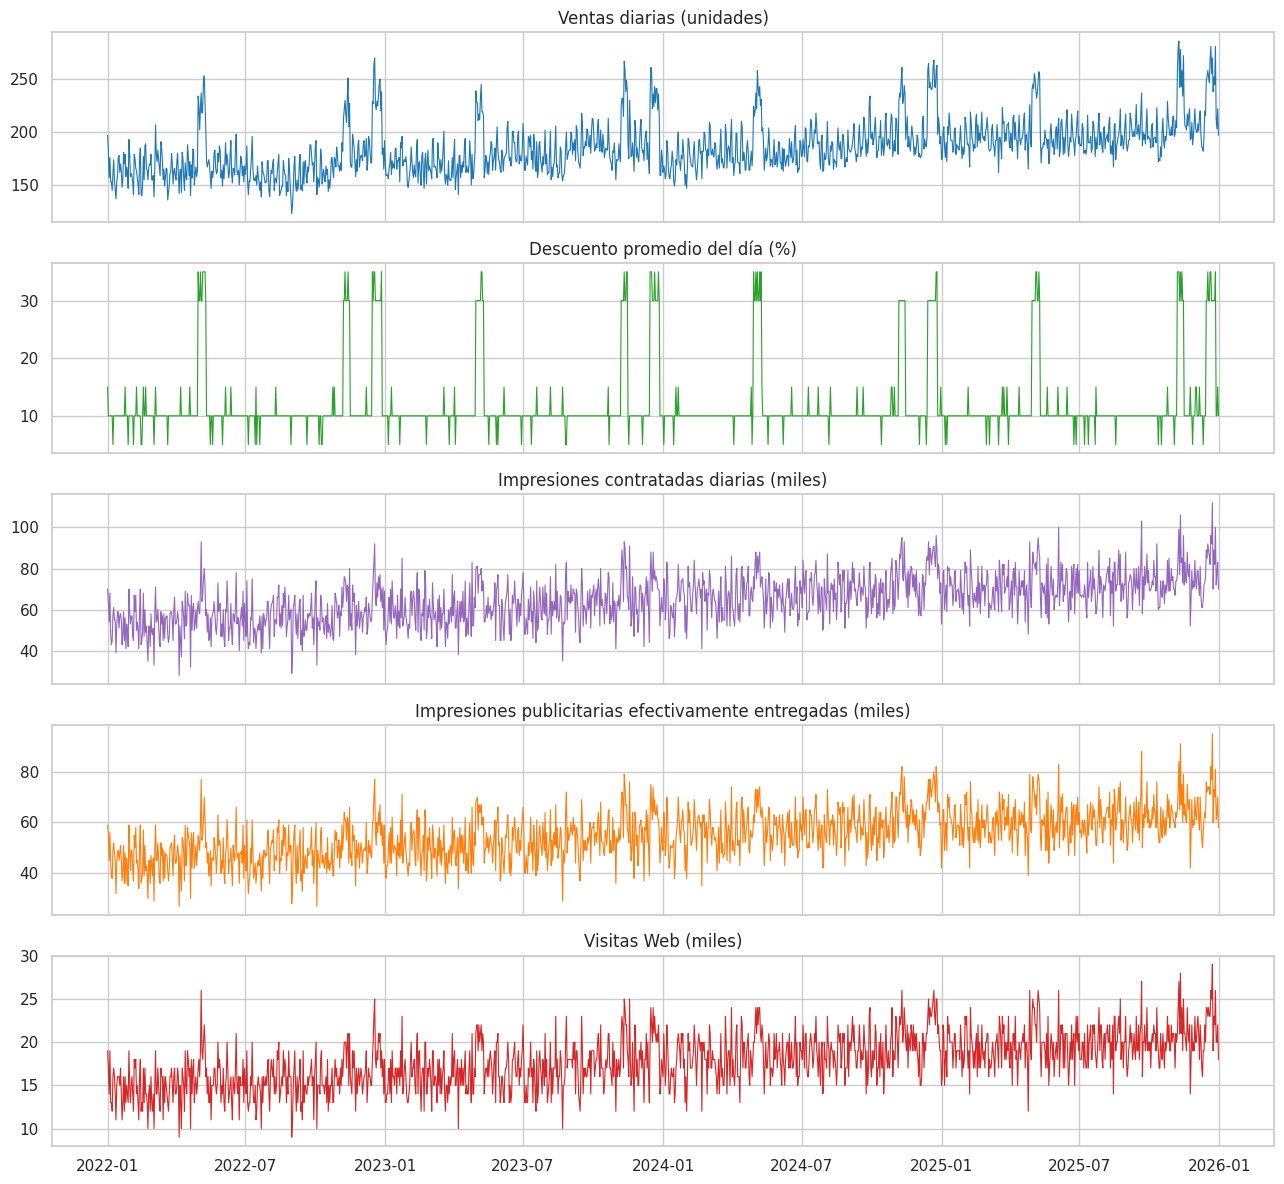

In [15]:
fig, axes = plt.subplots(5, 1, figsize=(13, 12), sharex=True)

axes[0].plot(df.index, df["ventasUnidades"], color="tab:blue", linewidth=0.8)
axes[0].set_title("Ventas diarias (unidades)")

axes[1].plot(df.index, df["descuentoPorc"], color="tab:green", linewidth=0.8)
axes[1].set_title("Descuento promedio del día (%)")

axes[2].plot(df.index, df["impresionesContratadas"], color="tab:purple", linewidth=0.8)
axes[2].set_title("Impresiones contratadas diarias (miles)")

axes[3].plot(df.index, df["impresionesAds"], color="tab:orange", linewidth=0.8)
axes[3].set_title("Impresiones publicitarias efectivamente entregadas (miles)")

axes[4].plot(df.index, df["visitasWeb"], color="tab:red", linewidth=0.8)
axes[4].set_title("Visitas Web (miles)")

plt.tight_layout()
plt.show()


Las ventas muestran picos muy marcados y recurrentes tres veces por
año —en cada uno de los 4 años de la serie—, exactamente en las fechas de Hot Sale, CyberMonday y
Navidad, además de una leve tendencia creciente a lo largo del período. El tráfico web y las
impresiones publicitarias muestran **patrones prácticamente idénticos** entre sí (los mismos picos,
en las mismas fechas, año tras año), mientras que el descuento promedio sólo se dispara puntualmente
durante las ventanas de campaña.


/tmp/ipykernel_779/3169943289.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="nombreDia", y="ventasUnidades", order=ordenDias, palette="Blues")


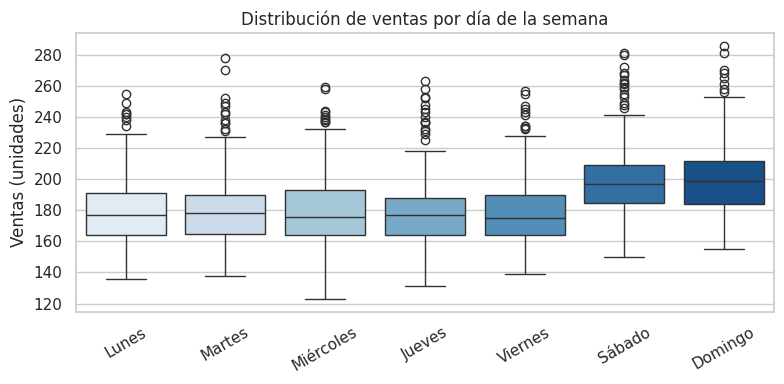

In [16]:
# Relación ventas vs. día de la semana
plt.figure(figsize=(8, 4))
ordenDias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
df_plot = df.copy()
df_plot["nombreDia"] = df_plot["diaSemana"].map(dict(enumerate(ordenDias)))
sns.boxplot(data=df_plot, x="nombreDia", y="ventasUnidades", order=ordenDias, palette="Blues")
plt.title("Distribución de ventas por día de la semana")
plt.xlabel("")
plt.ylabel("Ventas (unidades)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Se visualiza un leve incremento los "fines de semana"
patrón habitual en e-commerce (más tiempo libre para navegar y comprar). Esto sugiere que
`esFinSemana` puede ser una variable explicativa útil.

## Tratamiento del problema de fuga de datos (dataleakage)
Una situación bastante habitual en soluciones de machine learning es el problema de fuga de datos.
Ocurre cuando un modelo utiliza para entrenar información que no estará disponible en el momento de la predicción.

En este ejemplo:

- `visitasWeb` representa tráfico observado, es decir la cantidad de visitas efectivamente registradas en un día.
- `impresionesAds` representa impresiones efectivamente entregadas.

 Dichas variables no son conocidas de manera anticipada , es decir no son datos disponibles al momento de la predicción, por lo tanto deben ser excluidas.


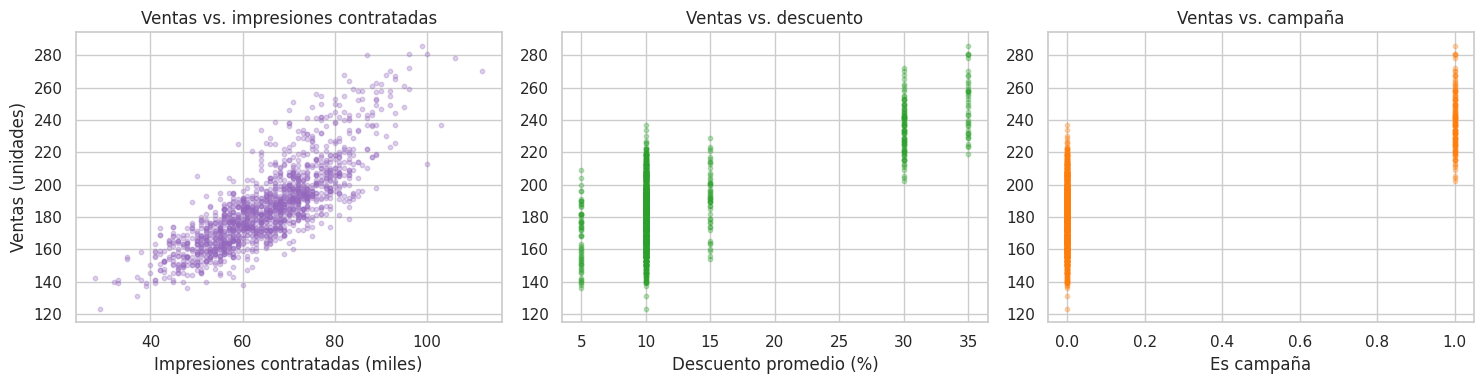

In [17]:
# Relación ventas vs. variables disponibles antes de la predicción
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df["impresionesContratadas"], df["ventasUnidades"], alpha=0.3, s=10, color="tab:purple")
axes[0].set_xlabel("Impresiones contratadas (miles)")
axes[0].set_ylabel("Ventas (unidades)")
axes[0].set_title("Ventas vs. impresiones contratadas")

axes[1].scatter(df["descuentoPorc"], df["ventasUnidades"], alpha=0.3, s=10, color="tab:green")
axes[1].set_xlabel("Descuento promedio (%)")
axes[1].set_title("Ventas vs. descuento")

axes[2].scatter(df["esCampania"], df["ventasUnidades"], alpha=0.3, s=10, color="tab:orange")
axes[2].set_xlabel("Es campaña")
axes[2].set_title("Ventas vs. campaña")

plt.tight_layout()
plt.show()


Las impresiones contratadas  muestran
una nube de puntos con tendencia positiva muy clara respecto de las ventas,
 El descuento también muestra una relación positiva marcada,
con un grupo de puntos claramente separado en la zona de descuentos altos (>30%): son,
precisamente, los días de campaña. Esta impresión visual la vamos a cuantificar a continuación con
una matriz de correlación.

## 4. Análisis de correlación para selección de variables de entrada

Como ya dijimos para evitar *data leakage*, las variables candidatas al modelo deben ser variables que estén
disponibles al momento de hacer la predicción.

En particular:

- `visitasWeb` se excluye porque representa tráfico observado y no conocido de antemano para el
  día futuro.
- `impresionesAds` representa impresiones efectivamente entregadas se excluye debido a que no será un dato conocido de antemano para el día futuro.

- `impresionesContratadas` sí puede conocerse anticipadamente porque representa el volumen
  contratado/planificado de una campaña.
- `descuentoPorc`, `esFinSemana` y `esCampania` son variables planificables/calendario.


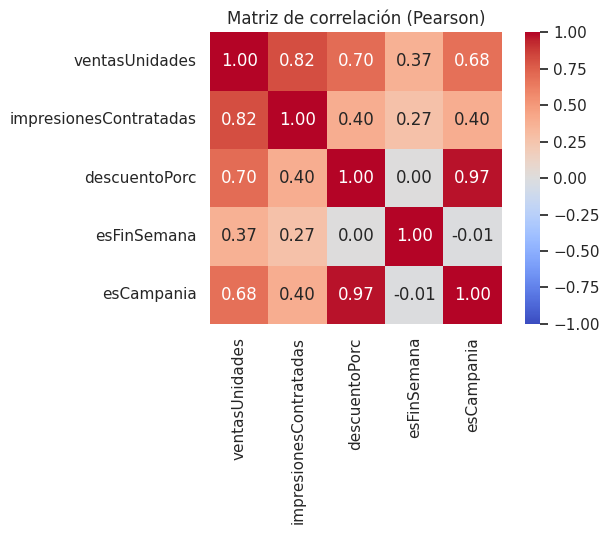

,ventasUnidades,impresionesContratadas,descuentoPorc,esFinSemana,esCampania
ventasUnidades,1.000000,0.815707,0.699188,0.371899,0.681591
impresionesContratadas,0.815707,1.000000,0.397441,0.269329,0.396413
descuentoPorc,0.699188,0.397441,1.000000,0.003300,0.969873
esFinSemana,0.371899,0.269329,0.003300,1.000000,-0.009329
esCampania,0.681591,0.396413,0.969873,-0.009329,1.000000


In [18]:
candidatas = [
    "ventasUnidades",
    "impresionesContratadas",
    "descuentoPorc",
    "esFinSemana",
    "esCampania"
]
corr = df[candidatas].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matriz de correlación (Pearson)")
plt.tight_layout()
plt.show()

corr


# Correlación con la variable objetivo
Finalmente **esFinSemana** no tiene una correlación fuerte con **ventasUnidades** , por lo tanto será descartada.
# Correlación de las variables candidatas como predictores.

 **descuentoPorc y esCampania** tienen fuerte correlación entre sí, por lo tanto aportan información redundante , para reducir la complejidad se elige una de las dos, la que tiene mayor correlación con la variable objetivo.

In [67]:
variablesExogenasCandidatas = [
    "impresionesContratadas",
    "descuentoPorc"

]


## 5. Preprocesamiento: variables de rezago (lag features)

KNN no conoce por sí mismo la naturaleza temporal de los datos. Por eso incorporamos variables
de rezago que utilizan únicamente información histórica.

### Variables conocidas antes de predecir

- `impresionesContratadas`: volumen publicitario planificado/contratado.
- `descuentoPorc`: descuento previsto para ese día, es un dato planificado de antemano


Estas variables se utilizan **sin rezago** porque su valor futuro puede conocerse antes de la
predicción.

### Variables históricas

- `ventasLag7`: ventas de hace 7 días.
- `ventasRollMean7`: promedio de ventas de los 7 días anteriores.
- `ventasMismaSemanaAnioAnterior`: referencia a la misma semana del año anterior.
.


In [68]:
dfVentasPreprocesadoCompleto = df.copy()

#Ventas hace 7 días
dfVentasPreprocesadoCompleto["ventasLag7"] = (
    dfVentasPreprocesadoCompleto["ventasUnidades"].shift(7)
)

#Promedio de ventas de los 7 días anteriores
dfVentasPreprocesadoCompleto["ventasRollMean7"] = (
    dfVentasPreprocesadoCompleto["ventasUnidades"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

# Promedio móvil centrado de 7 días desplazado 364 días:
# utiliza información histórica de un año anterior.
dfVentasPreprocesadoCompleto["ventasRoll7Centrado"] = (
    dfVentasPreprocesadoCompleto["ventasUnidades"]
    .rolling(window=7, center=True, min_periods=5)
    .mean()
)
#Misma semana del año anterior.
dfVentasPreprocesadoCompleto["ventasMismaSemanaAnioAnterior"] = (
    dfVentasPreprocesadoCompleto["ventasRoll7Centrado"].shift(364)
)

# Variables exógenas conocidas antes del día a predecir
variablesCalendario = [
    "impresionesContratadas",
    "descuentoPorc"

]

columnas = (
    [

        "ventasLag7",
        "ventasRollMean7",
        "ventasMismaSemanaAnioAnterior"
    ]
    + variablesCalendario
)

# Control explícito contra el leakage
assert "visitasWeb" not in columnas, "ERROR: visitasWeb no debe ser una feature del modelo."
assert "impresionesAds" not in columnas, "ERROR: impresionesAds no debe ser una feature del modelo."

print("Features finales del modelo:")
for c in columnas:
    print(" -", c)

dfVentasPreprocesadoCompleto[["ventasUnidades"] + columnas].head(10)


Features finales del modelo:
 - ventasLag7
 - ventasRollMean7
 - ventasMismaSemanaAnioAnterior
 - impresionesContratadas
 - descuentoPorc


,ventasUnidades,ventasLag7,ventasRollMean7,ventasMismaSemanaAnioAnterior,impresionesContratadas,descuentoPorc
fecha,,,,,,
2022-01-01,197,NaN,NaN,NaN,70,15
2022-01-02,182,NaN,NaN,NaN,64,10
2022-01-03,157,NaN,NaN,NaN,54,10
2022-01-04,176,NaN,NaN,NaN,68,10
2022-01-05,153,NaN,NaN,NaN,48,10
2022-01-06,153,NaN,NaN,NaN,43,10
2022-01-07,145,NaN,NaN,NaN,45,10
2022-01-08,161,197.0,166.142857,NaN,57,5
2022-01-09,174,182.0,161.000000,NaN,61,10


Las primeras filas quedan con `NaN` por los rezagos. El rezago de 364 días requiere
aproximadamente un año completo de historia previa.

La variable `impresionesContratadas` no requiere rezago porque se supone conocida de antemano,
igual que el calendario de descuentos y campañas.


In [69]:
nAntes = len(dfVentasPreprocesadoCompleto)
dfVentasPreprocesado = dfVentasPreprocesadoCompleto.dropna(subset=columnas + ["ventasUnidades"]).copy()
nDespues = len(dfVentasPreprocesado)

print(f"Registros antes de eliminar NaN por rezago: {nAntes}")
print(f"Registros después: {nDespues}  (se perdieron {nAntes - nDespues} filas iniciales, "
      f"≈{(nAntes - nDespues)/365:.1f} años, por el rezago de 364 días)")
print(f"Nuevo rango de fechas útil: {dfVentasPreprocesado.index.min().date()} a {dfVentasPreprocesado.index.max().date()}")
dfVentasPreprocesado[["ventasUnidades"] + columnas].describe().round(2)


Registros antes de eliminar NaN por rezago: 1461
Registros después: 1096  (se perdieron 365 filas iniciales, ≈1.0 años, por el rezago de 364 días)
Nuevo rango de fechas útil: 2023-01-01 a 2025-12-31


,ventasUnidades,ventasLag7,ventasRollMean7,ventasMismaSemanaAnioAnterior,impresionesContratadas,descuentoPorc
count,1096.00,1096.00,1096.00,1096.00,1096.00,1096.00
mean,190.73,190.56,190.63,180.47,67.75,11.92
std,23.30,23.12,18.56,19.13,10.85,6.34
min,141.00,141.00,157.43,145.86,35.00,5.00
25%,175.00,174.75,177.71,167.14,60.00,10.00
50%,187.00,187.00,188.71,177.07,68.00,10.00
75%,201.25,201.00,197.29,187.57,74.25,10.00
max,286.00,286.00,263.14,254.29,112.00,35.00


Se pierde aproximadamente el primer año
completo de la serie (2022): el dataset utilizable para entrenar y evaluar el modelo queda acotado
a 2023-2025

## 6. Particionamiento train / test respetando el orden temporal (*time split*)

En series temporales **nunca** hacemos un `train_test_split` aleatorio: eso mezclaría fechas
futuras en el entrenamiento y fechas pasadas en el test, generando una fuga de información y una
evaluación irreal del modelo (el modelo "vería el futuro" durante el entrenamiento).

En su lugar, usamos un **particion cronológico**: todo lo anterior a una fecha de particion es
entrenamiento, todo lo posterior es test. Usamos un split 80% / 20%.


Entrenamiento: 2023-01-01 a 2025-05-25  (876 días)
Test:          2025-05-26 a 2025-12-31  (220 días)


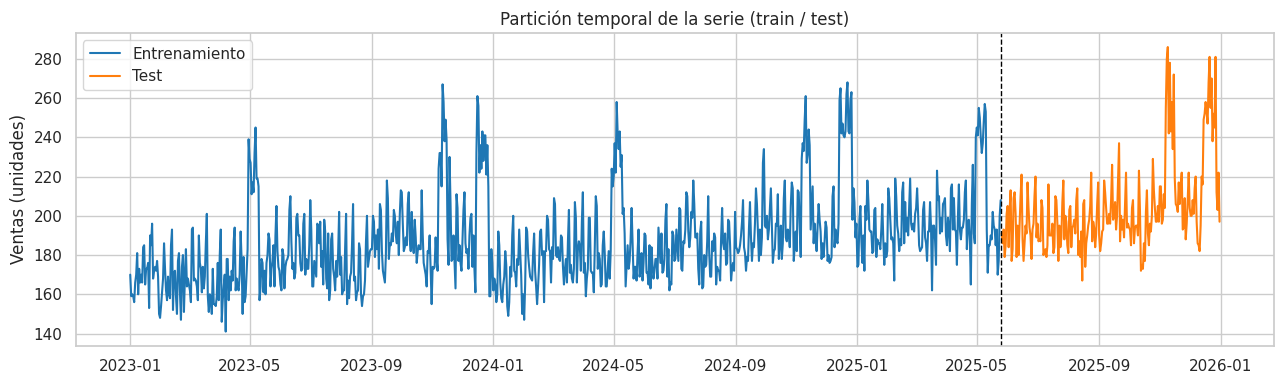

In [70]:
particion = int(len(dfVentasPreprocesado) * 0.8)

train = dfVentasPreprocesado.iloc[:particion]
test = dfVentasPreprocesado.iloc[particion:]

print(f"Entrenamiento: {train.index.min().date()} a {train.index.max().date()}  ({len(train)} días)")
print(f"Test:          {test.index.min().date()} a {test.index.max().date()}  ({len(test)} días)")

plt.figure(figsize=(13, 4))
plt.plot(train.index, train["ventasUnidades"], label="Entrenamiento", color="tab:blue")
plt.plot(test.index, test["ventasUnidades"], label="Test", color="tab:orange")
plt.axvline(train.index.max(), color="black", linestyle="--", linewidth=1)
plt.title("Partición temporal de la serie (train / test)")
plt.ylabel("Ventas (unidades)")
plt.legend()
plt.tight_layout()
plt.show()


El conjunto de entrenamiento (azul) cubre aproximadamente los
primeros 2 años y medio —incluyendo varios ciclos completos de Hot Sale, CyberMonday y Navidad—, y
el conjunto de test (naranja) queda como un tramo continuo hacia el final de la serie, sin
mezclarse con el entrenamiento. Esto simula el escenario real: entrenamos con el pasado y
evaluamos qué tan bien predecimos un futuro que el modelo nunca vio, incluyendo la última
temporada de campañas de fin de año.

In [72]:
X_train, y_train = train[columnas], train["ventasUnidades"]
X_test, y_test = test[columnas], test["ventasUnidades"]

print("X_train:", X_train.shape, " | X_test:", X_test.shape)


X_train: (876, 5)  | X_test: (220, 5)


### Escalado de variables

KNN es un algoritmo **basado en distancias**. Por lo tanto es necesario realizar un escalado

In [73]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



## 7. Entrenamiento del modelo KNN Regressor

El hiperparámetro más importante de KNN es **k** (la cantidad de vecinos que se promedian para
generar la predicción):

- Un **k muy chico** hace que el modelo sea muy sensible al ruido (sobreajuste / *overfitting*).
- Un **k muy grande** promedia demasiadas observaciones y el modelo pierde capacidad de capturar
  patrones locales, como el salto puntual de ventas durante una campaña (subajuste /
  *underfitting*).

Para elegir el mejor valor de K se calcula la raiz cuadrada de la cantidad de instancias del conjunto de entrenamiento


raiz cuadrada de la cantidad de instancias de entrenamiento

In [74]:
k=round(np.sqrt(len(X_train_scaled)))
print(k)

30


In [75]:
# Entrenamos el modelo final con todo el conjunto de entrenamiento
modelo_knn = KNeighborsRegressor(n_neighbors=k, weights="distance")
modelo_knn.fit(X_train_scaled, y_train)

print(
    f"Modelo KNN entrenado con k={k} sobre "
    f"{X_train_scaled.shape[0]} observaciones y "
    f"{X_train_scaled.shape[1]} variables de entrada."
)


Modelo KNN entrenado con k=30 sobre 876 observaciones y 5 variables de entrada.


## 8. Evaluación sobre el conjunto de test

Ahora sí usamos el conjunto de test —que el modelo nunca vio, ni siquiera durante la selección de
hiperparámetros— para medir el desempeño real del modelo.


In [76]:
y_pred = modelo_knn.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)

print("Métricas sobre el conjunto de TEST")
print("-" * 40)
print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.2f} unidades")
print(f"MAE  : {mae:.2f} unidades")
print(f"Ventas medias en test: {y_test.mean():.2f} unidades  (MAE representa el "
      f"{100*mae/y_test.mean():.1f}% de las ventas medias)")


Métricas sobre el conjunto de TEST
----------------------------------------
R²   : 0.8047
RMSE : 9.97 unidades
MAE  : 7.28 unidades
Ventas medias en test: 203.92 unidades  (MAE representa el 3.6% de las ventas medias)


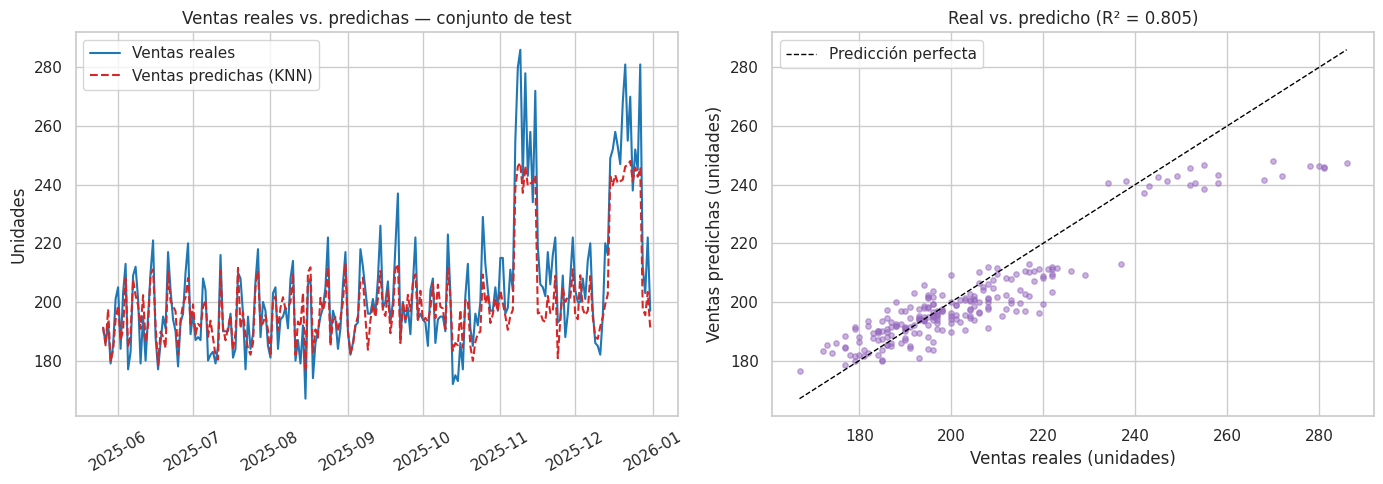

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(test.index, y_test.values, label="Ventas reales", color="tab:blue")
axes[0].plot(test.index, y_pred, label="Ventas predichas (KNN)", color="tab:red", linestyle="--")
axes[0].set_title("Ventas reales vs. predichas — conjunto de test")
axes[0].set_ylabel("Unidades")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=30)

axes[1].scatter(y_test, y_pred, alpha=0.5, s=15, color="tab:purple")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lims, lims, color="black", linestyle="--", linewidth=1, label="Predicción perfecta")
axes[1].set_xlabel("Ventas reales (unidades)")
axes[1].set_ylabel("Ventas predichas (unidades)")
axes[1].set_title(f"Real vs. predicho (R² = {r2:.3f})")
axes[1].legend()

plt.tight_layout()
plt.show()


- El gráfico de **ventas reales vs. predichas en el tiempo** muestra que el modelo logra seguir de
  cerca tanto el nivel general de ventas como buena parte de su variabilidad de corto plazo, ya que la curva de los valores predichos acompaña con sus picos y valles a la curva de los valores reales



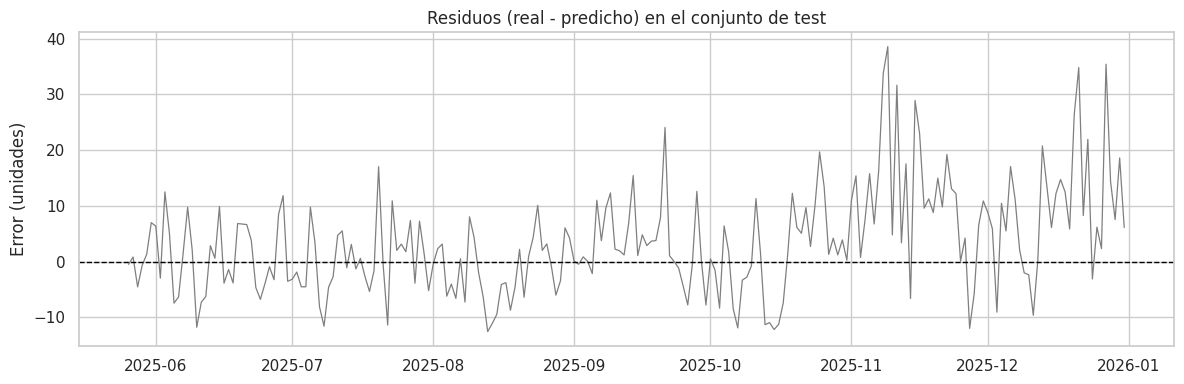

Residuo medio: 3.42 unidades (cercano a 0 indica que el modelo no tiene sesgo sistemático relevante)
Desvío estándar de los residuos: 9.37 unidades


In [78]:
residuos = y_test.values - y_pred

plt.figure(figsize=(12, 4))
plt.plot(test.index, residuos, color="tab:gray", linewidth=0.9)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Residuos (real - predicho) en el conjunto de test")
plt.ylabel("Error (unidades)")
plt.tight_layout()
plt.show()

print(f"Residuo medio: {residuos.mean():.2f} unidades (cercano a 0 indica que el modelo no tiene "
      f"sesgo sistemático relevante)")
print(f"Desvío estándar de los residuos: {residuos.std():.2f} unidades")


- Los **residuos** oscilan alrededor de 0 sin un patrón temporal marcado
no hay una tendencia
  creciente ni ciclos evidentes en el error

## 9. Conclusiones

### Corrección del data leakage

El resultado de la evaluación del modelo es excelente para el problema planteado. Ya que obtiene las siguientes métricas
- **R² ≈ 0.805**
- **MAE ≈ 7 unidades**

Aproximadamente 7 unidades de error para la organización de logística de entrega una semana antes es un valor sumamente aceptable.

